## Importing Basic Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Dataset Loading

In [13]:
dataset = pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [14]:
dataset.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [15]:
dataset.shape

(200, 5)

In [16]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Segregate and Zipping Dataset

In [17]:
Income = dataset['Annual Income (k$)'].values
Spend = dataset['Spending Score (1-100)'].values
x = np.array(list(zip(Income, Spend)))         

## Finding the optimized K Value

In [18]:
from sklearn.cluster import KMeans
K_MAX = 10
sse = []
for k in range(1, K_MAX+1):
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    km.fit(x)
    sse.append(km.inertia_)

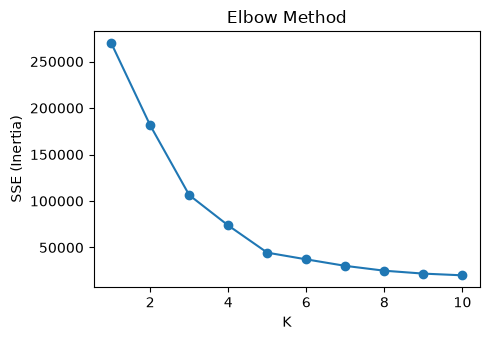

In [19]:
plt.figure(figsize = (5, 3.5))
plt.plot(range(1, K_MAX+1), sse, marker = 'o')
plt.xlabel("K")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

## Fitting the K-means to the dataset with K = 5

In [23]:
model = KMeans(n_clusters = 5, random_state = 0)
y_means = model.fit_predict(x)
print(model.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [25.72727273 79.36363636]]


## **Visualizing the clusters for K = 5**
### Cluster1: Customers with medium income and medium spend
### Cluster2: Customers with high income and high spend
### Cluster3: Customers with high income and low spend
### Cluster4: Customers with low income and low spend
### Cluster5: Customers with low income and high spend

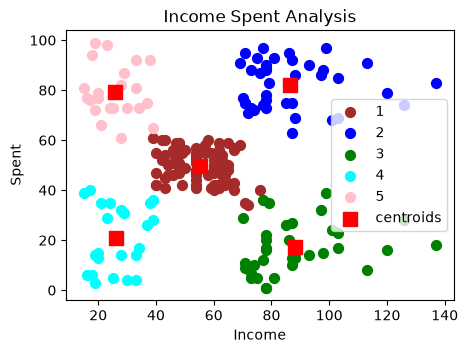

In [24]:
plt.figure(figsize=(5, 3.5))
plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 50, c = 'brown', label = '1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 50, c = 'blue', label = '2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s = 50, c = 'green', label = '3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s = 50, c = 'cyan', label = '4')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s = 50, c = 'pink', label = '5')

plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s = 100, marker = 's', c = 'red', label = 'centroids')
plt.title('Income Spent Analysis')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.legend()
plt.show()